In [20]:
from sklearn.datasets import fetch_olivetti_faces
import matplotlib.pyplot as plt
from sklearn.manifold import LocallyLinearEmbedding
from matplotlib import offsetbox
import numpy as np
from sklearn.decomposition import PCA

In [21]:
# 1. Charger les images (elles sont nativement en niveaux de gris)
olivetti = fetch_olivetti_faces()

# 2. Vérifications
n_samples = len(olivetti.images)
image_shape = olivetti.images[0].shape

print(f"Nombre d'images : {n_samples}")
print(f"Dimensions de chaque image : {image_shape}")

# 3. Transformer chaque image en vecteur 1D
# olivetti.data contient déjà les images aplaties (4096,)
X = olivetti.data 

# 4. Vérification de la taille finale de la matrice X
print(f"Taille finale de la matrice X : {X.shape}")


Nombre d'images : 400
Dimensions de chaque image : (64, 64)
Taille finale de la matrice X : (400, 4096)


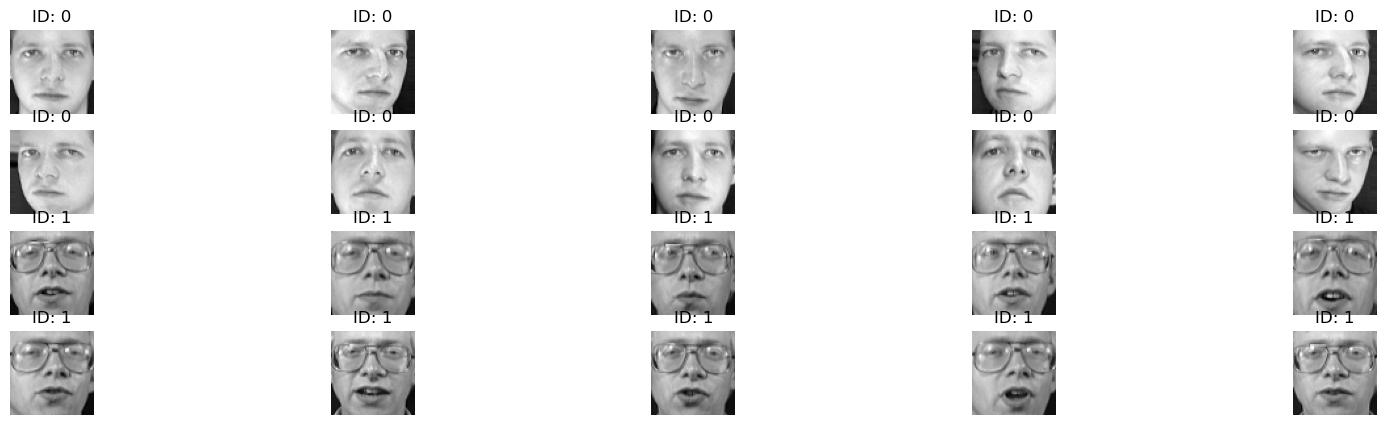

In [22]:
fig, axes = plt.subplots(4, 5, figsize=(20, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(olivetti.images[i], cmap='gray')
    ax.axis('off')
    ax.set_title(f"ID: {olivetti.target[i]}")
plt.show()

In [23]:
# Traitement : Réduction de 4096 dimensions à 2
lle = LocallyLinearEmbedding(n_neighbors=15, n_components=2, method='standard')
X_lle = lle.fit_transform(X)

print(f"Nouvelle forme de X : {X_lle.shape}") # Doit être (400, 2)


Nouvelle forme de X : (400, 2)


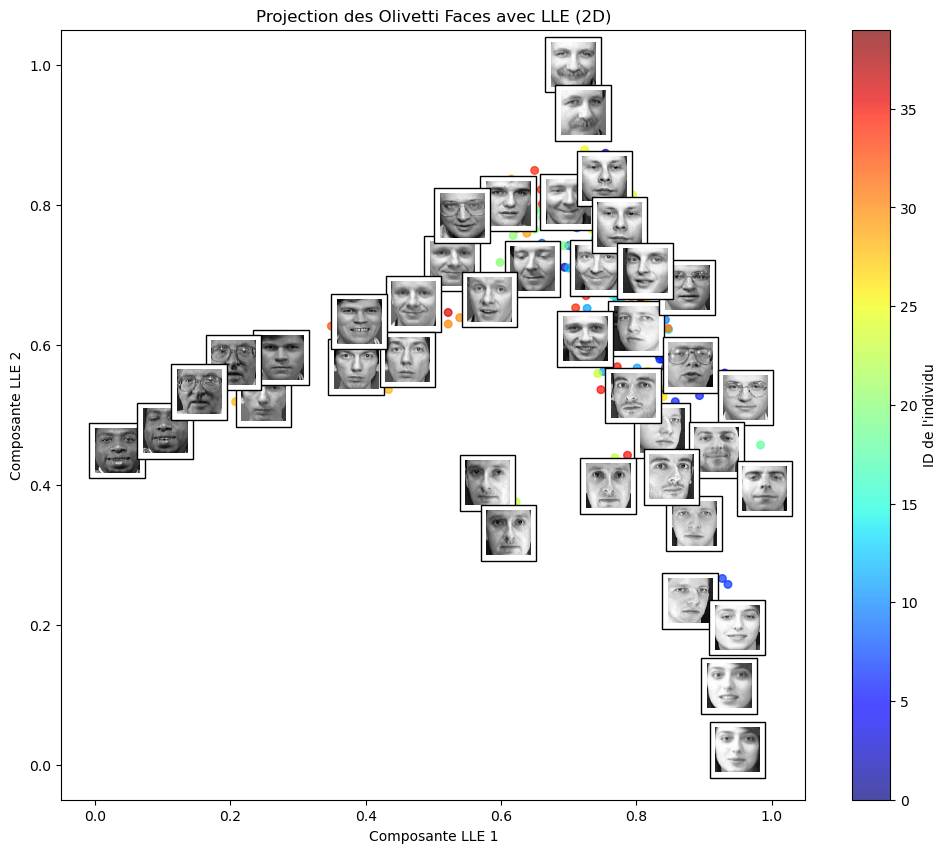

In [24]:
def plot_embedding(X_projected, title=None):
    # Normalisation des données pour l'affichage (entre 0 et 1)
    x_min, x_max = np.min(X_projected, 0), np.max(X_projected, 0)
    X_projected = (X_projected - x_min) / (x_max - x_min)

    plt.figure(figsize=(12, 10))
    ax = plt.subplot(111)
    
    # Affichage des points colorés par individu (target)
    scatter = ax.scatter(X_projected[:, 0], X_projected[:, 1], 
                         c=olivetti.target, cmap='jet', s=30, alpha=0.7)
    
    # Ajout des vignettes (images miniatures) sur le graphique
    if hasattr(offsetbox, 'AnnotationBbox'):
        shown_images = np.array([[1., 1.]])  # Pour éviter la superposition
        for i in range(X_projected.shape[0]):
            dist = np.sum((X_projected[i] - shown_images) ** 2, 1)
            if np.min(dist) < 4e-3: # Ne pas afficher si trop proche d'une autre image
                continue
            shown_images = np.r_[shown_images, [X_projected[i]]]
            
            imagebox = offsetbox.AnnotationBbox(
                offsetbox.OffsetImage(olivetti.images[i], cmap=plt.cm.gray, zoom=0.5),
                X_projected[i])
            ax.add_artist(imagebox)

    plt.title(title)
    plt.colorbar(scatter, label="ID de l'individu")
    plt.xlabel("Composante LLE 1")
    plt.ylabel("Composante LLE 2")
    plt.show()

# Appel de la fonction avec vos données transformées
plot_embedding(X_lle, "Projection des Olivetti Faces avec LLE (2D)")


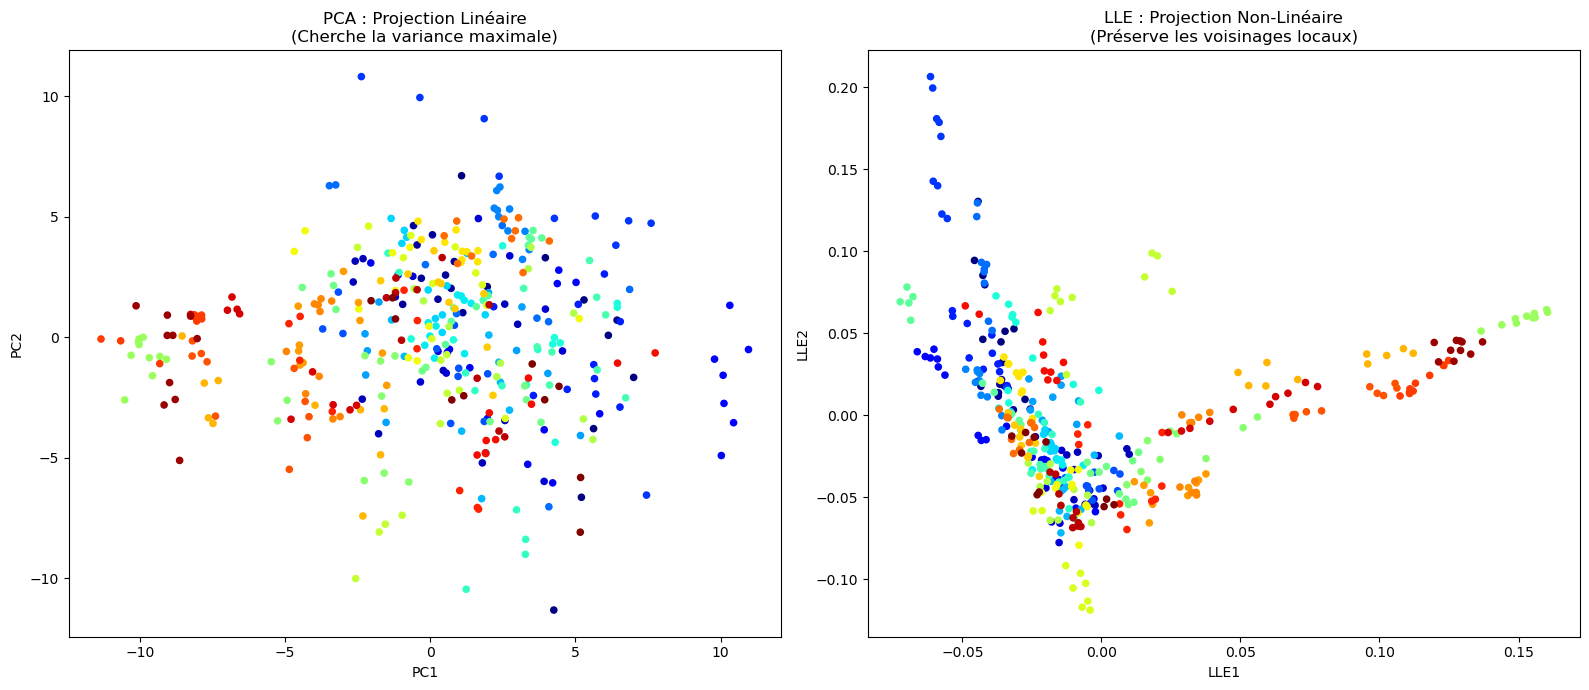

In [25]:
# 1. Calcul de la PCA (Linéaire)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 2. Calcul du LLE (Non-linéaire)
lle = LocallyLinearEmbedding(n_neighbors=15, n_components=2, method='standard')
X_lle = lle.fit_transform(X)

# 3. Affichage comparatif
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot PCA
ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=olivetti.target, cmap='jet', s=20)
ax1.set_title("PCA : Projection Linéaire\n(Cherche la variance maximale)")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")

# Plot LLE
ax2.scatter(X_lle[:, 0], X_lle[:, 1], c=olivetti.target, cmap='jet', s=20)
ax2.set_title("LLE : Projection Non-Linéaire\n(Préserve les voisinages locaux)")
ax2.set_xlabel("LLE1")
ax2.set_ylabel("LLE2")

plt.tight_layout()
plt.show()

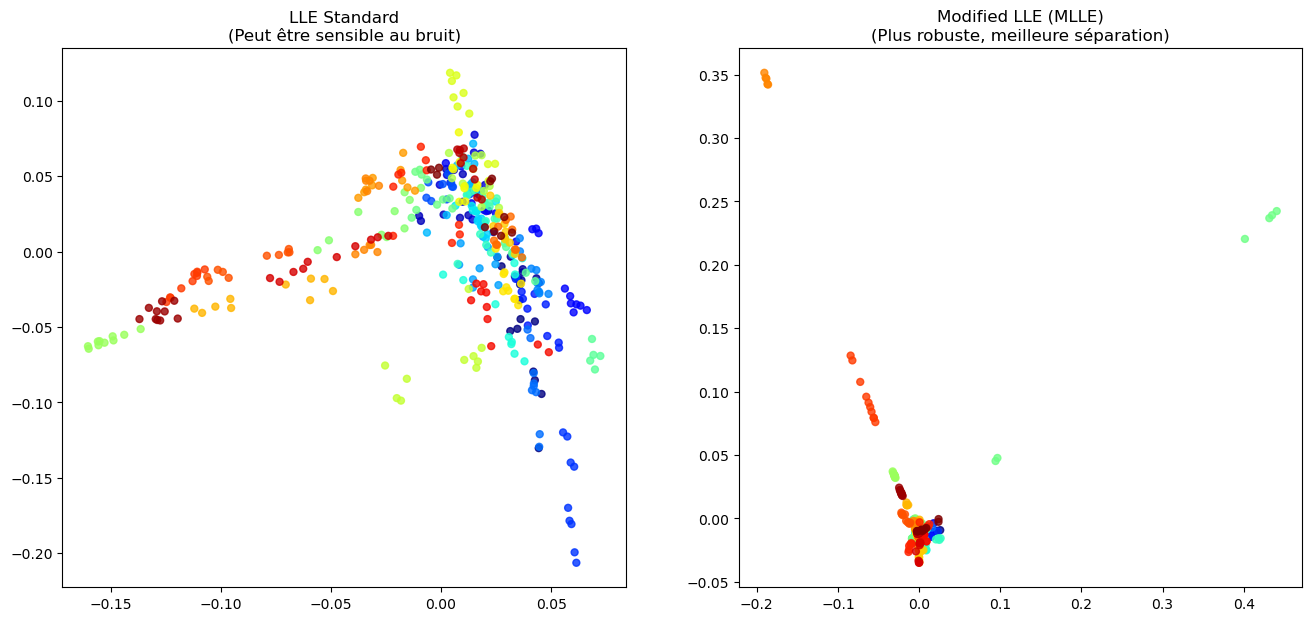

In [26]:
# 1. LLE Standard
lle_std = LocallyLinearEmbedding(n_neighbors=15, n_components=2, method='standard')
X_std = lle_std.fit_transform(X)

# 2. Modified LLE (MLLE)
# Note : n_neighbors doit être supérieur à n_components
lle_mod = LocallyLinearEmbedding(n_neighbors=15, n_components=2, method='modified')
X_mlle = lle_mod.fit_transform(X)

# 3. Affichage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot LLE Standard
ax1.scatter(X_std[:, 0], X_std[:, 1], c=olivetti.target, cmap='jet', s=25, alpha=0.8)
ax1.set_title("LLE Standard\n(Peut être sensible au bruit)")

# Plot MLLE
ax2.scatter(X_mlle[:, 0], X_mlle[:, 1], c=olivetti.target, cmap='jet', s=25, alpha=0.8)
ax2.set_title("Modified LLE (MLLE)\n(Plus robuste, meilleure séparation)")

plt.show()

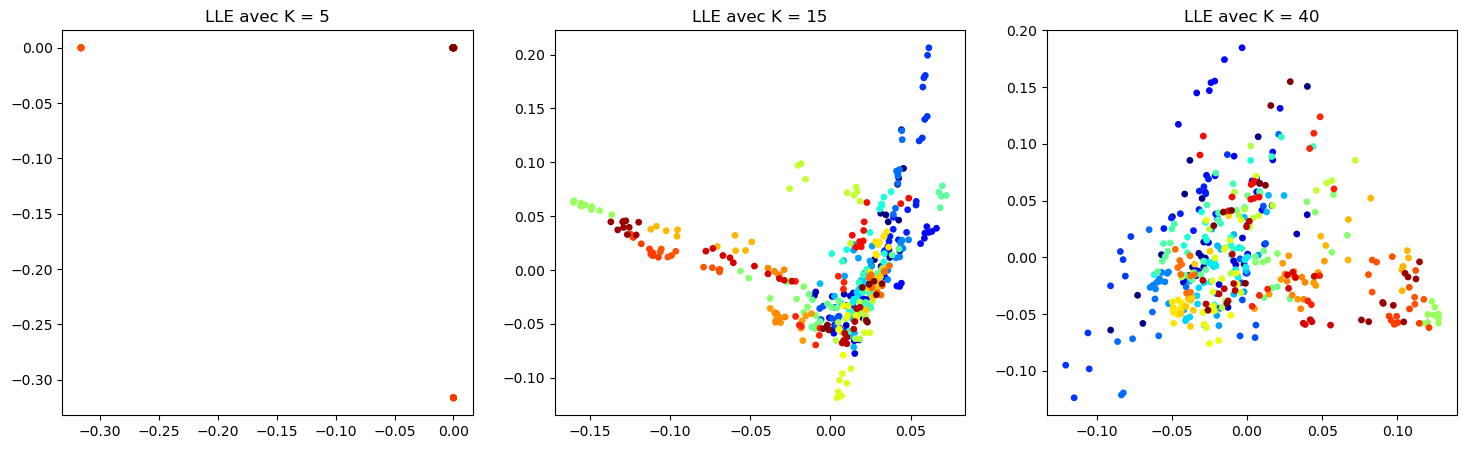

In [27]:
ks = [5, 15, 40]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, k in enumerate(ks):
    lle_test = LocallyLinearEmbedding(n_neighbors=k, n_components=2)
    X_test = lle_test.fit_transform(X)
    axes[i].scatter(X_test[:, 0], X_test[:, 1], c=olivetti.target, cmap='jet', s=15)
    axes[i].set_title(f"LLE avec K = {k}")

plt.show()